<a href="https://colab.research.google.com/github/merinrose4007/DSA-class-activity/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [419]:
import matplotlib.pyplot as plt

In [420]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
data = load_wine()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] =data.target
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [421]:
df.shape

(178, 14)

In [422]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [423]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [424]:
df.isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [425]:
num_cols = df.select_dtypes(include= 'float64')

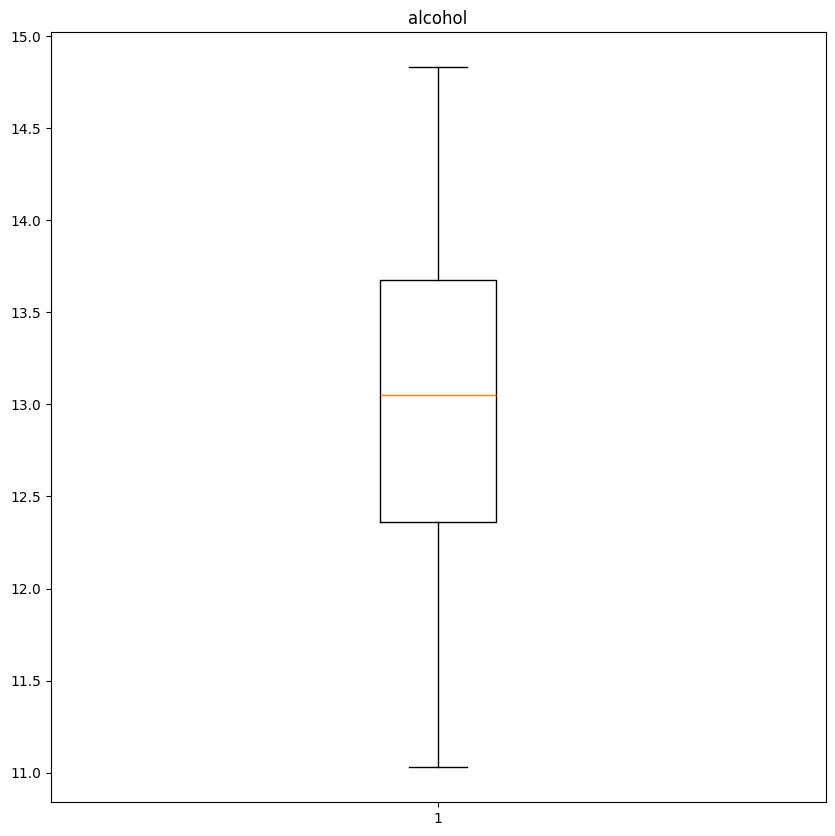

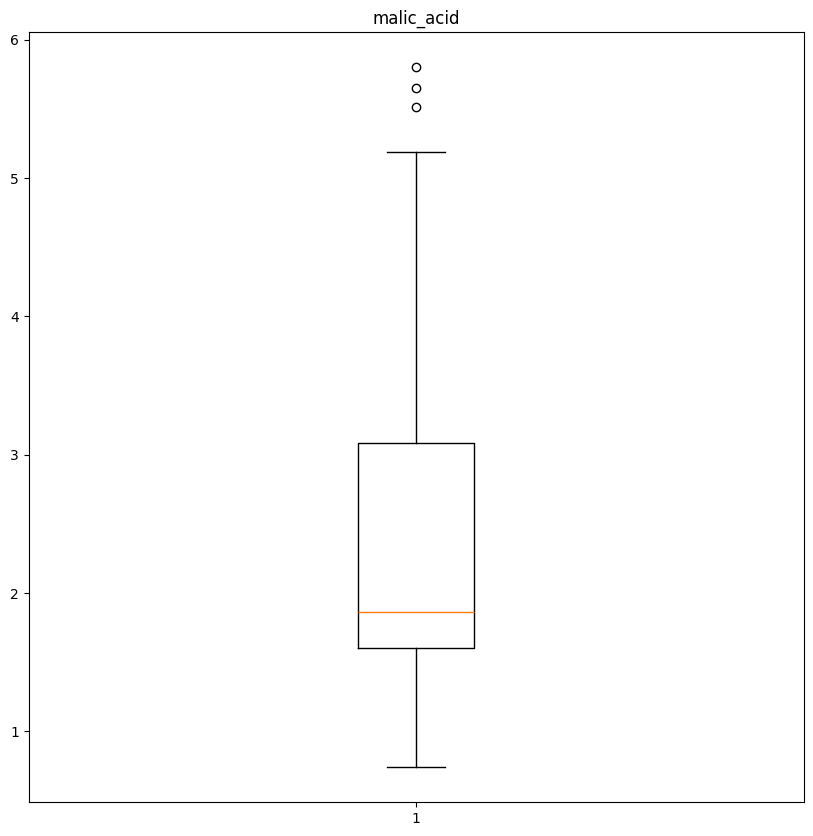

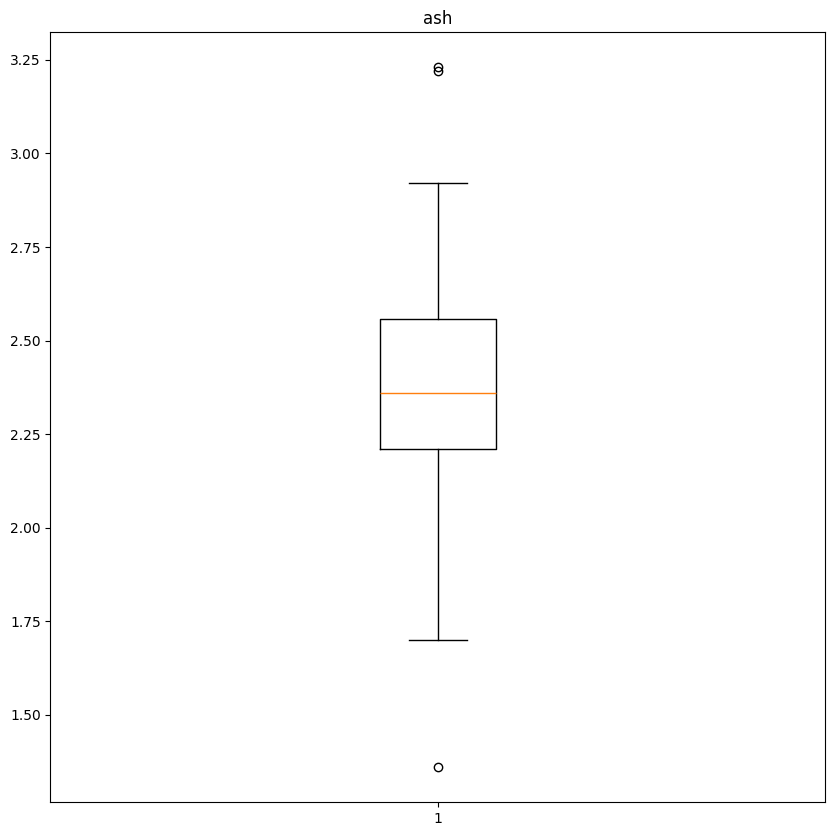

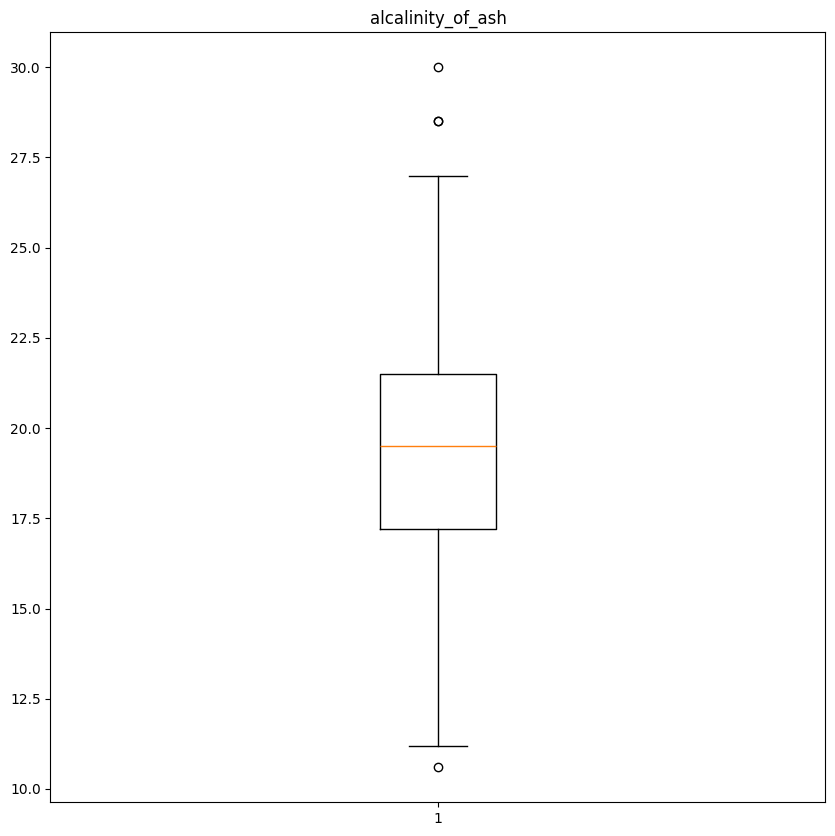

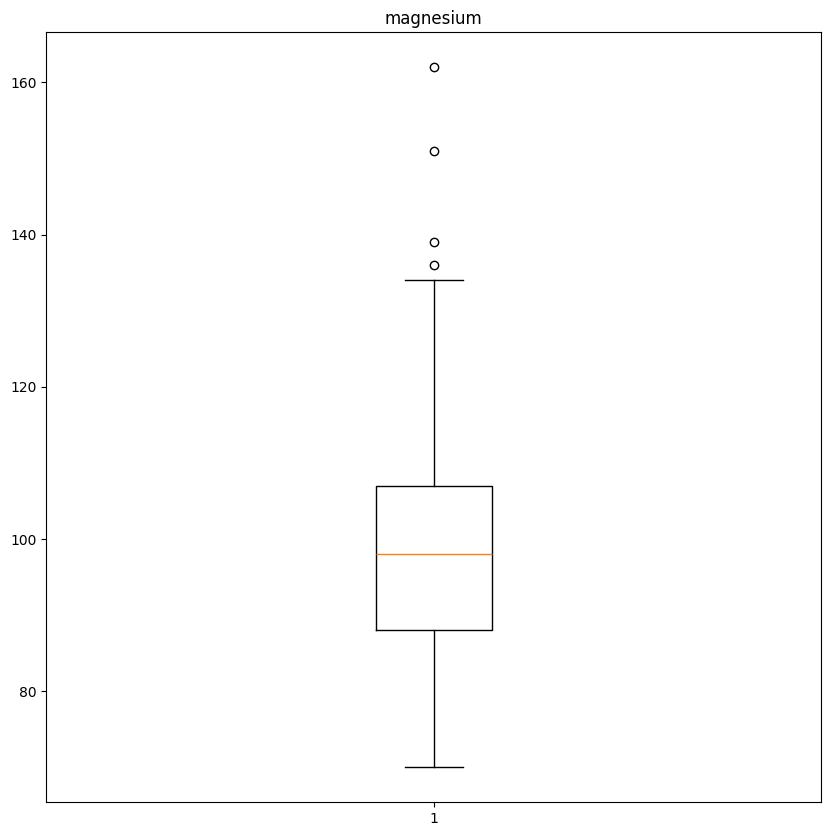

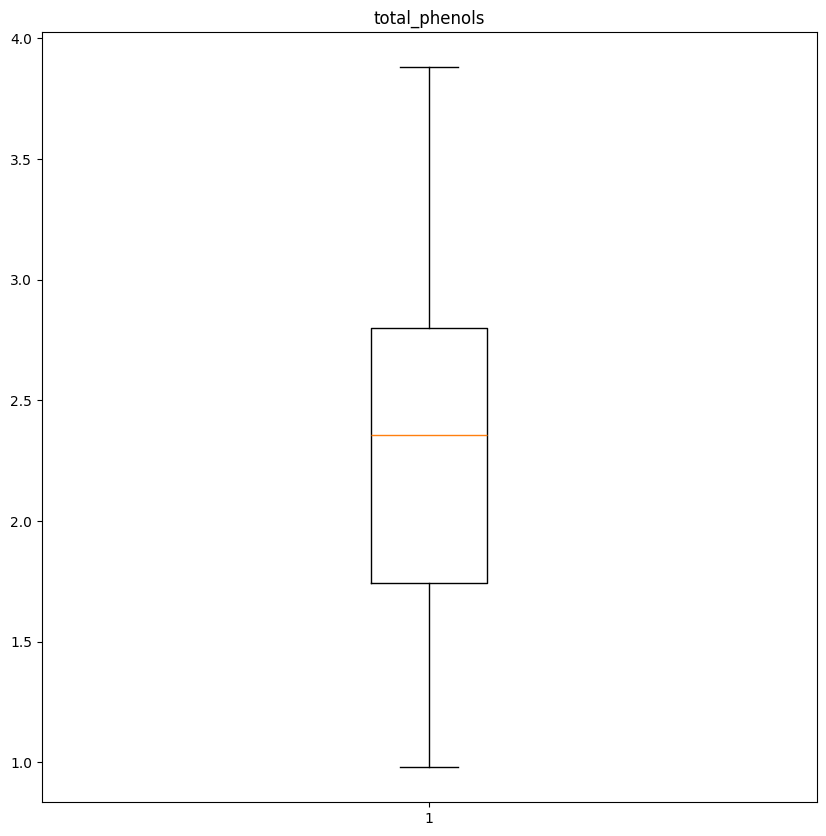

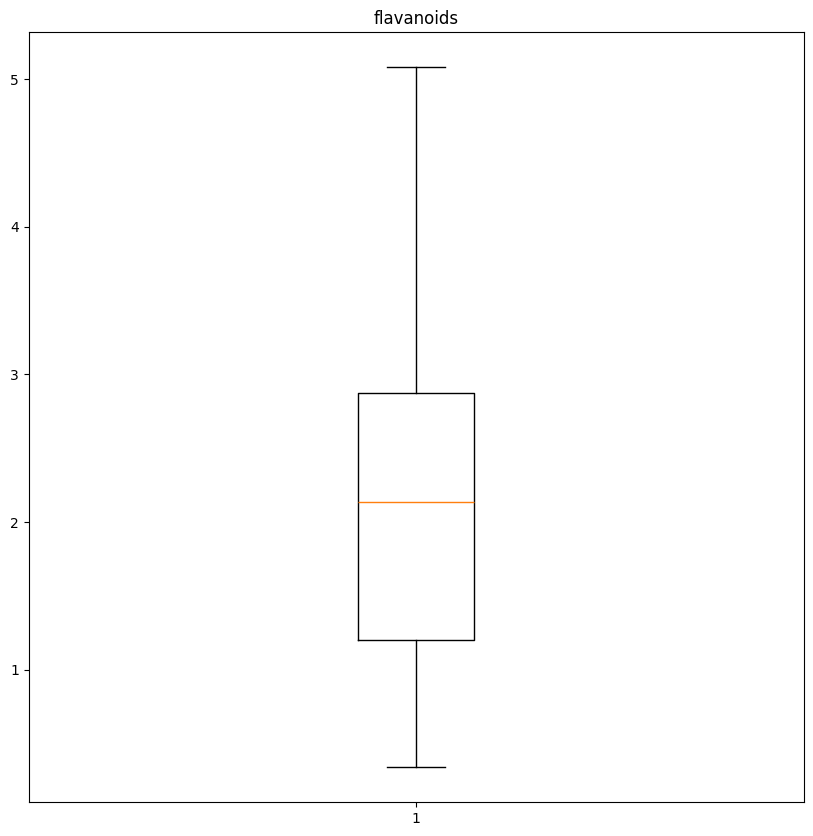

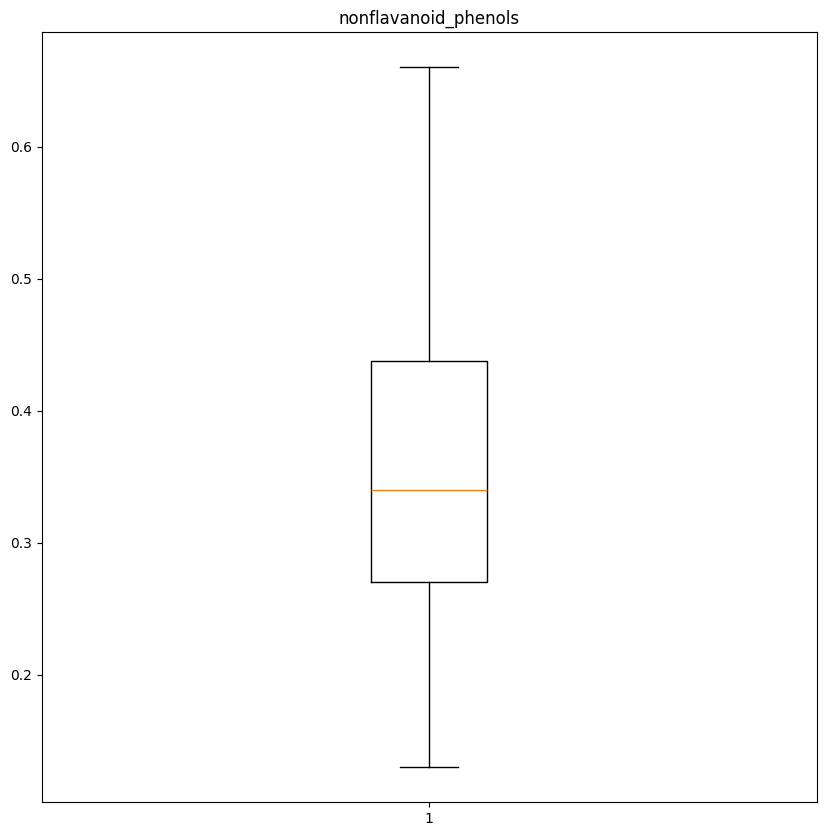

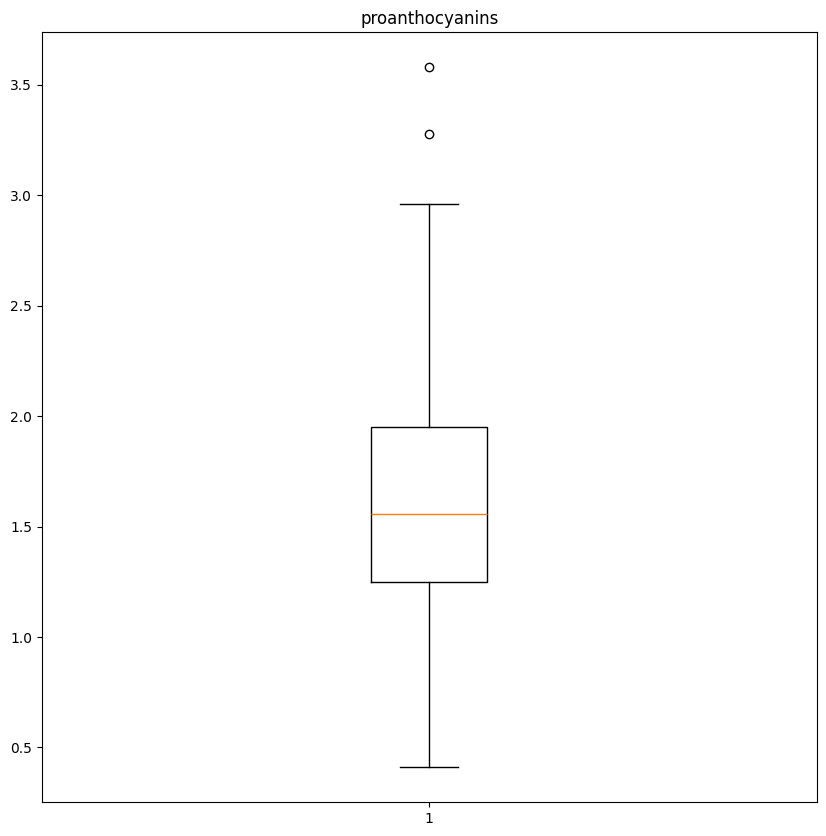

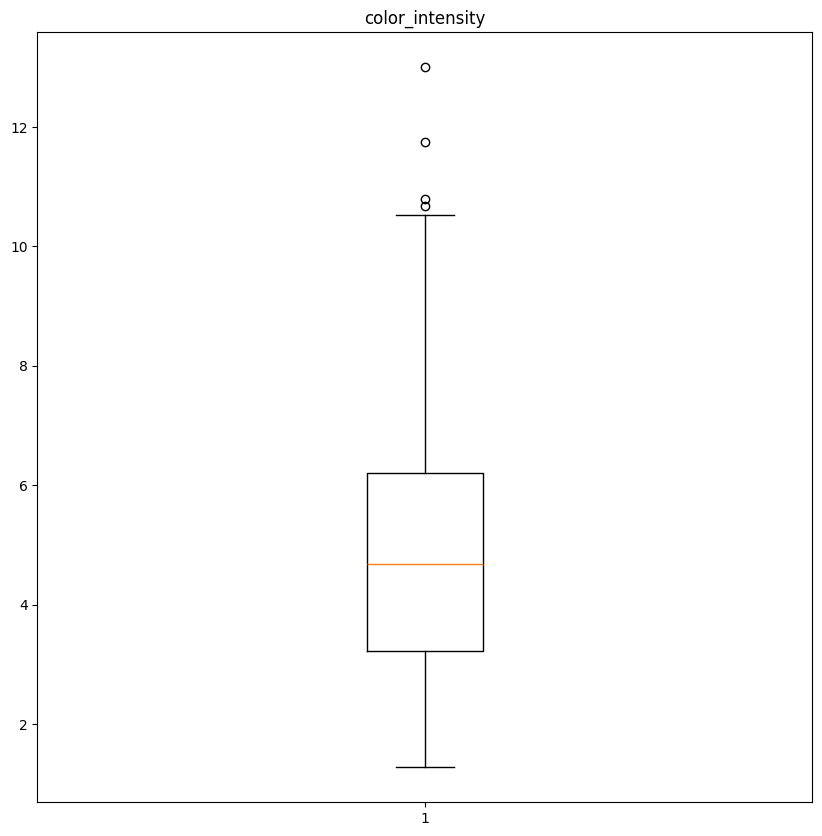

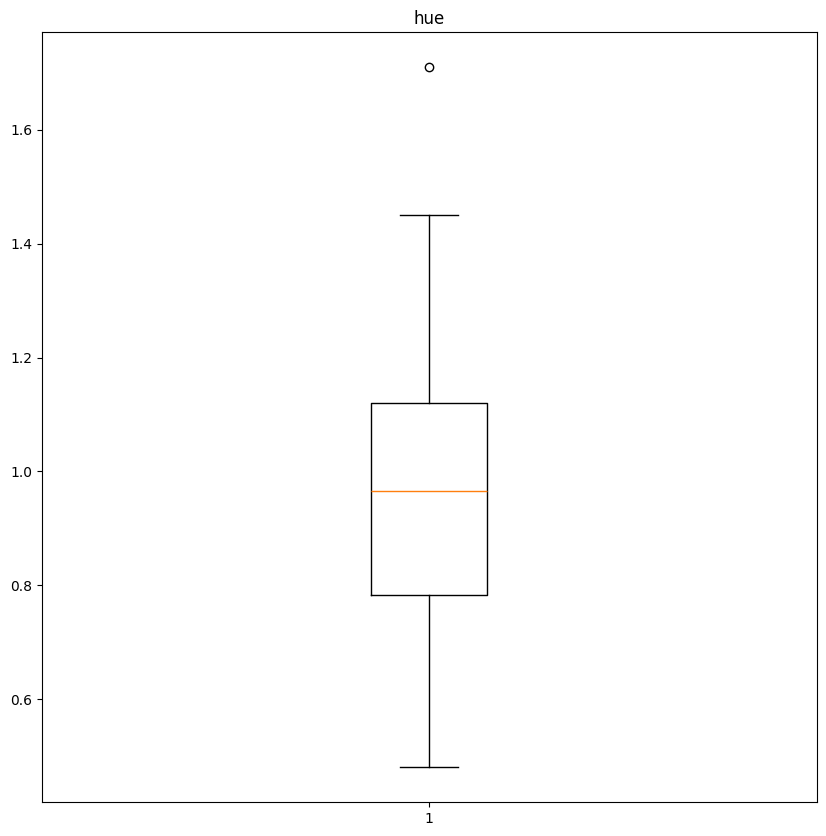

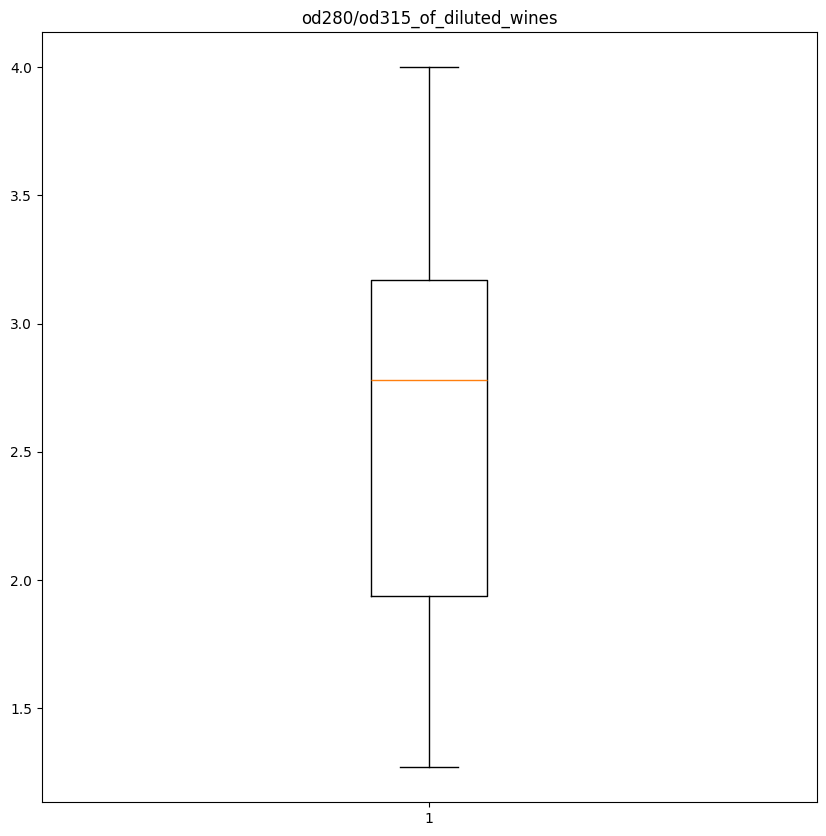

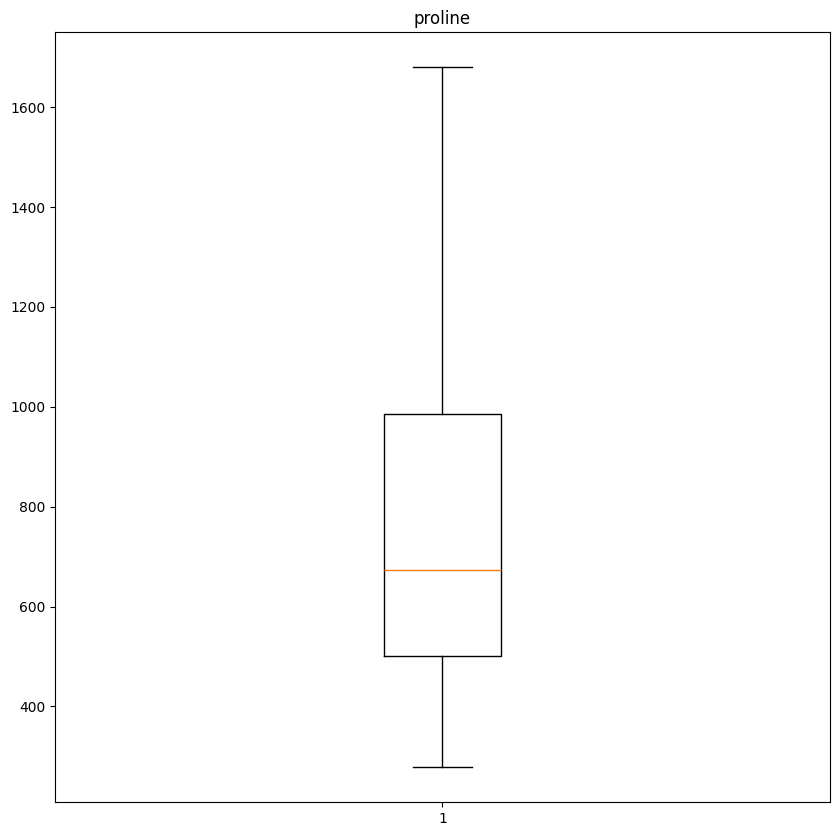

In [426]:
for i in num_cols:
  plt.figure(figsize = (10,10))
  plt.boxplot(df[i])
  plt.title(i)

In [427]:
from sklearn.feature_selection import SelectKBest, f_classif

In [428]:
selector_skbest = SelectKBest(score_func= f_classif, k =5)
y = df['target']
X = df.drop(columns='target')
X.shape

(178, 13)

In [429]:
X_new = selector_skbest.fit_transform(X, y)
select_feature_indices = selector_skbest.get_support(indices=True)
select_feature = X.columns[select_feature_indices]
print(select_feature)

Index(['alcohol', 'flavanoids', 'color_intensity',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [430]:
feature_score_skb = selector_skbest.scores_
for feature, score in zip(X.columns, feature_score_skb):
  print(f"feature :{feature}, Score: {score}")

feature :alcohol, Score: 135.07762424283948
feature :malic_acid, Score: 36.94342496318376
feature :ash, Score: 13.312901199989989
feature :alcalinity_of_ash, Score: 35.77163740730817
feature :magnesium, Score: 12.429584338150178
feature :total_phenols, Score: 93.73300962036775
feature :flavanoids, Score: 233.92587268154838
feature :nonflavanoid_phenols, Score: 27.575417146965727
feature :proanthocyanins, Score: 30.27138317022791
feature :color_intensity, Score: 120.66401844100372
feature :hue, Score: 101.31679539029965
feature :od280/od315_of_diluted_wines, Score: 189.97232057888206
feature :proline, Score: 207.92037390217828


In [431]:
X_new.shape

(178, 5)

In [432]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.25)

In [433]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score
rc = RandomForestClassifier(n_estimators=25, max_depth=5, max_leaf_nodes=5, min_samples_split=5, random_state=42)

In [434]:
rc.fit(X_train, y_train)
y_pred = rc.predict(X_test)
print('Accuracy',accuracy_score(y_test, y_pred))

Accuracy 0.9555555555555556


In [435]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.95      0.95      0.95        19
           2       0.91      1.00      0.95        10

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [436]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.95      0.95      0.95        19
           2       0.91      1.00      0.95        10

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [437]:
data = load_wine()
df = pd.DataFrame(data.data, columns = data.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [438]:
from sklearn.feature_selection import VarianceThreshold

selector_var = VarianceThreshold(threshold=0.5)
X_new_wine_var =selector_var.fit_transform(df)
df.shape

(178, 13)

In [439]:
X_new_wine_var.shape

(178, 8)

In [440]:
selector_var.get_feature_names_out()

array(['alcohol', 'malic_acid', 'alcalinity_of_ash', 'magnesium',
       'flavanoids', 'color_intensity', 'od280/od315_of_diluted_wines',
       'proline'], dtype=object)

In [441]:
df.var()

,0
alcohol,0.659062
malic_acid,1.248015
ash,0.075265
alcalinity_of_ash,11.152686
magnesium,203.989335
total_phenols,0.391690
flavanoids,0.997719
nonflavanoid_phenols,0.015489
proanthocyanins,0.327595
color_intensity,5.374449


In [442]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y = True)
X.shape

(150, 4)

In [443]:
estimator = RandomForestClassifier(n_estimators=50, random_state=42)
selector_rfe = RFE(estimator=estimator, n_features_to_select=2, step=1)


In [444]:
selector_rfe.fit(X, y)
print(selector_rfe.ranking_)

[2 3 1 1]


In [445]:
selected_features_rfe = selector_rfe.get_support(indices =True)
feature_names =load_iris().feature_names
select_feature_names = [feature_names[i] for i in selected_features_rfe]
print(feature_names)
print(select_feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['petal length (cm)', 'petal width (cm)']


In [446]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [447]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])
pca_df['species'] = y
display(pca_df.head())
display(pca.explained_variance_ratio_)

,PC1,PC2,species
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


array([0.72962445, 0.22850762])

In [448]:
pca_full = PCA().fit(X_scaled)
print(pca_full.explained_variance_ratio_)

[0.72962445 0.22850762 0.03668922 0.00517871]


In [449]:
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

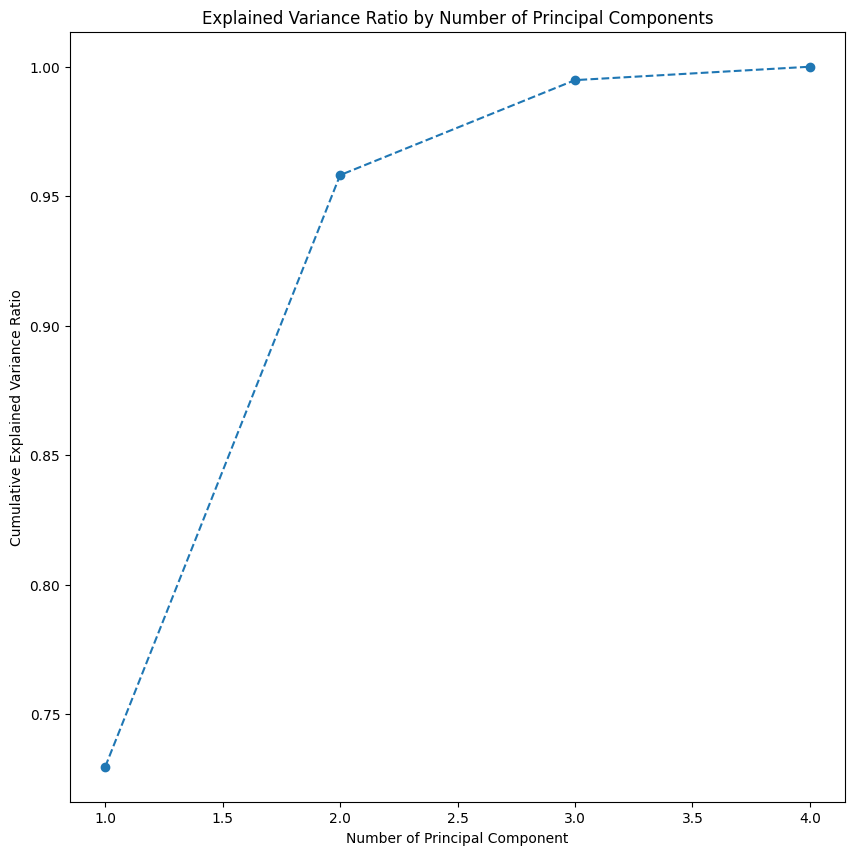

In [450]:
plt.figure(figsize= (10, 10))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), cum_var, marker = 'o', linestyle = '--')
plt.xlabel('Number of Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.show()

#Breast Cancer Dataset

In [451]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] =data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [452]:
df.duplicated().sum()

np.int64(0)

In [453]:
df.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [454]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [455]:
X = df.drop(columns = 'target')
y =df['target']

In [456]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X)

In [457]:
pca_full = PCA().fit(X_scaled)
print(pca_full.explained_variance_ratio_)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


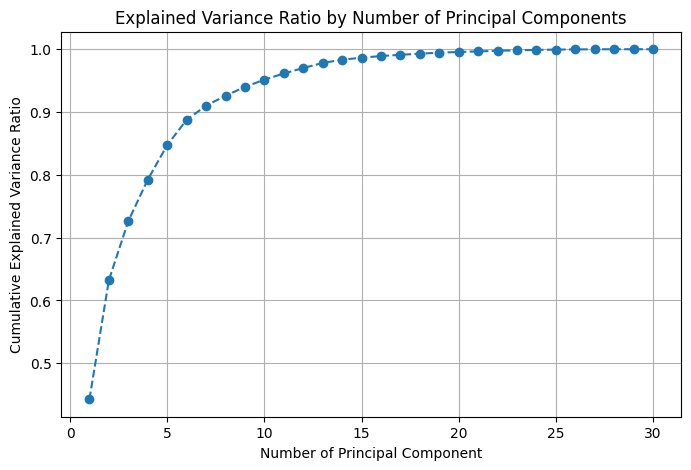

In [458]:
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize= (8,5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1), cum_var, marker = 'o', linestyle = '--')
plt.xlabel('Number of Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid()
plt.show()

In [510]:
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])
pca_df['target'] = y
display(pca_df.head())
display(pca.explained_variance_ratio_)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,target
0,9.192837,1.948583,-1.123166,-3.633731,1.195110,1.411424,2.159370,0
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775,0.028656,0.013358,0
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086,0.541452,-0.668166,0
3,7.122953,10.275589,-3.232790,-0.152547,2.960878,3.053422,1.429911,0
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747,-1.226495,-0.936213,0


array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734])

In [511]:
X = pca_df.drop(columns = 'target')
y = pca_df['target']

In [512]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [513]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.986013986013986

In [515]:
y_pred = lr.predict(X_train)

In [516]:
accuracy_score(y_train, y_pred)

0.9765258215962441